In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('mode.chained_assignment', None)
warnings.simplefilter("ignore", category=RuntimeWarning)

import random
import os
from juno_classes import *

from scipy.integrate import trapz


def extract_base_exponent_scientific(number):
    exponent = int(np.log10(number))
    base = number / (10 ** exponent)
    return base, exponent

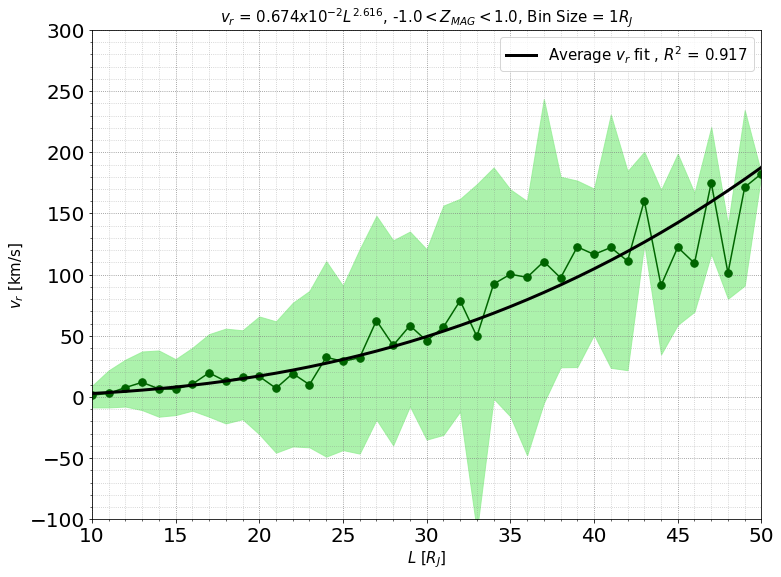

In [ ]:
bin_sizes = 1
binsize_plot = [1]
filename = 'radial_fitting_for_paper_df.pkl'
picklefile = open(filename,'rb')
sorted_q_dfs_desc_R = pickle.load(picklefile)
sorted_q_dfs_desc_R = sorted_q_dfs_desc_R.iloc[np.where(np.abs(sorted_q_dfs_desc_R['Z_MAG']) < 1 )].dropna()

end = 'fits_6_to_30_4min_12_nofilter_point4thresh_thetas_newmeans_keepcone'
save = False


def extract_base_exponent_scientific(number):
    exponent = int(np.log10(number))
    base = number / (10 ** exponent)
    return base, exponent


array_to_be_averaged = sorted_q_dfs_desc_R


R_spher_here = array_to_be_averaged['  "R"']
Z_mag_here = array_to_be_averaged['Z_MAG']
R_cyl_here = np.sqrt(R_spher_here**2-Z_mag_here**2)

j=0
R_values = R_cyl_here

q_values_mhd = array_to_be_averaged['   "ur"'].iloc[np.where(array_to_be_averaged['   "ur"']>0)]


binned_q_array_mhd = []
binned_std = []

binned_R_array = [] 


factor = bin_sizes
j+=1

Rs = np.arange(10,51, factor)

for i in Rs:
    L = i
    average_L = i
    constrained_array_mhd = array_to_be_averaged.iloc[np.where(   (R_cyl_here > (L - factor/2))  &   (R_cyl_here < (L+factor/2)))]

    average_value_mhd = np.nanmean(constrained_array_mhd['   "ur"'])
    std = np.nanstd(constrained_array_mhd['   "ur"'], ddof=1)


    
    
    binned_q_array_mhd.append(average_value_mhd)
    binned_std.append(std)


    binned_R_array.append(average_L)

both_averages = [binned_R_array,binned_q_array_mhd,binned_std]

df2 = np.asarray(both_averages)
df_combined = np.asarray(both_averages)



X_mhd = np.log10(df2[0][np.where((df_combined[0] > 0) & (df_combined[1] >0))].reshape(-1,1))


Y_mhd = np.log10(df_combined[1][np.where((df_combined[0] > 0) & (df_combined[1] >0)) ].reshape(-1,1))




model_mhd = LinearRegression()
model_mhd.fit(X_mhd,Y_mhd)



mhd_intercept = 10**model_mhd.intercept_
mhd_slope = model_mhd.coef_[0]


y_pred_mhd = model_mhd.predict(X_mhd)


r2_q = r2_score(Y_mhd,y_pred_mhd)







mhd_base, mhd_exponent = extract_base_exponent_scientific(mhd_intercept)



mhd_base_value = mhd_base[0]
mhd_slope_value = mhd_slope[0]



yerror = (df_combined[2][np.where((df_combined[0] > 0) & (df_combined[1] >0)) ].reshape(-1,1))


fig,ax = plt.subplots(figsize=(12, 9), sharex='all')

size=3

df1 =sorted_q_dfs_desc_R.dropna()
df1['R_cyl'] = R_cyl_here
df1['r_bin'] = pd.cut(df1['R_cyl'], bins=np.arange(9.5, 51.5,1)) # 2 unit bin width
df1['ur']=df1['   "ur"']


percentiles = df1.groupby('r_bin')['ur'].quantile([0.05,0.1, 0.25, 0.5, 0.75, 0.9,0.95]).unstack()

bin_centers = percentiles.index.map(lambda x: x.mid)
ax.fill_between(bin_centers, percentiles[0.1], percentiles[0.9],color= 'lightgreen',alpha=0.75)


ax.plot(10**X_mhd, 10**Y_mhd.ravel(),markersize=5*size, color='darkgreen', marker='.')

ax.plot(10**X_mhd, 10**y_pred_mhd, color='k', linewidth=3, label=r'Average $v_r$ fit , $R^2$ = ' + str(round(r2_q, 3)))

ax.set_title(r'$v_r$ = ' + str(round(mhd_base_value, 3))+ r"$ x 10^{"+ str(round(mhd_exponent,3))+r'}$'+  r'$L^{'+str(round(mhd_slope_value,3))+ r'}$' + r', ' +  str(round(sorted_q_dfs_desc_R['Z_MAG'].min(), 2)) + r'$ < Z_{MAG} < $' + str(round(sorted_q_dfs_desc_R['Z_MAG'].max(), 2))+ r', Bin Size = ' +str(factor) +r'$R_J$', fontsize = 15)

ax.set_ylabel(r'$v_r$ [km/s]', fontsize = 15)
ax.legend(fontsize=15)
ax.set_ylim(-100,300)
ax.set_xlim(10,50)

#ax.set_xscale('log')
#ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=20)
plt.minorticks_on()
plt.grid(True, which='minor', axis='both', linestyle=':', color='gray', alpha=0.45)
plt.grid(True,which='major', axis='both', linestyle=':', color='gray', alpha=1)

#ax[0].set_ylim(-18,-13)
ax.set_xlabel(r'$L$ $[R_J]$',fontsize =15)
plt.savefig('vr_fiting.png', facecolor = 'white',dpi=300)
plt.show()


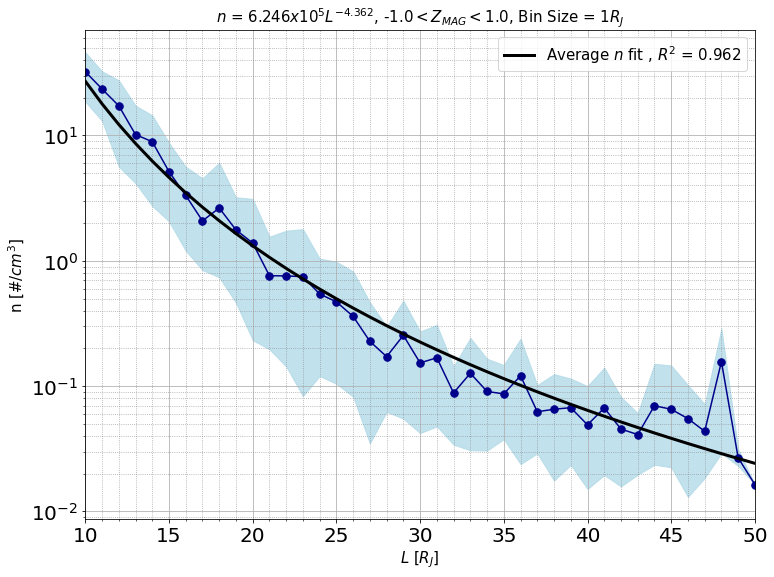

In [3]:
bin_sizes = 1
binsize_plot = [1]



def extract_base_exponent_scientific(number):
    exponent = int(np.log10(number))
    base = number / (10 ** exponent)
    return base, exponent


array_to_be_averaged = sorted_q_dfs_desc_R

j=0
R_values = R_cyl_here

q_values_mhd = array_to_be_averaged['      "n"']


binned_q_array_mhd = []


binned_R_array = [] 
binned_std = []



factor = bin_sizes
j+=1

Rs = np.arange(10,51, factor)

for i in Rs:
    L = i
    average_L = i
    constrained_array_mhd = array_to_be_averaged.iloc[np.where(   (R_cyl_here > (L - factor/2))  &   (R_cyl_here < (L+factor/2)))]


    average_value_mhd = np.nanmean(constrained_array_mhd['      "n"'])
    

    
    
    binned_q_array_mhd.append(average_value_mhd)

    binned_R_array.append(average_L)
    std = np.nanstd(constrained_array_mhd['      "n"'], ddof=1)
    binned_std.append(std)
both_averages = [binned_R_array,binned_q_array_mhd,binned_std]

df2 = np.asarray(both_averages)
df_combined = np.asarray(both_averages)


X_mhd = np.log10(df2[0][np.where((df_combined[0] > 0) & (df_combined[1] >0))].reshape(-1,1))


Y_mhd = np.log10(df_combined[1][np.where((df_combined[0] > 0) & (df_combined[1] >0)) ].reshape(-1,1))




model_mhd = LinearRegression()
model_mhd.fit(X_mhd,Y_mhd)





mhd_intercept = 10**model_mhd.intercept_
mhd_slope = model_mhd.coef_[0]



y_pred_mhd = model_mhd.predict(X_mhd)



r2_q = r2_score(Y_mhd,y_pred_mhd)








mhd_base, mhd_exponent = extract_base_exponent_scientific(mhd_intercept)


mhd_base_value = mhd_base[0]
mhd_slope_value = mhd_slope[0]




fig,ax = plt.subplots(figsize=(12, 9), sharex='all')




df1 =sorted_q_dfs_desc_R.dropna()
df1['R_cyl'] = R_cyl_here
df1['r_bin'] = pd.cut(df1['R_cyl'], bins=np.arange(9.5,51.5,1))  # 2 unit bin width
df1['n']=df1['      "n"']


percentiles = df1.groupby('r_bin')['n'].quantile([0.05,0.1, 0.25, 0.5, 0.75, 0.9,0.95]).unstack()

bin_centers = percentiles.index.map(lambda x: x.mid)



size=3
yerror = (df_combined[2][np.where((df_combined[0] > 0) & (df_combined[1] >0)) ].reshape(-1,1))
ax.fill_between(bin_centers, percentiles[0.1], percentiles[0.9],color= 'lightblue',alpha=0.75)
ax.plot(10**X_mhd, 10**Y_mhd.ravel(),markersize=5*size, color='darkblue', marker='.')



ax.plot(10**X_mhd, 10**y_pred_mhd, color='black', linewidth=3, label=r'Average $n$ fit , $R^2$ = ' + str(round(r2_q, 3)))

ax.set_title(r'$n$ = ' + str(round(mhd_base_value, 3))+ r"$ x 10^{"+ str(round(mhd_exponent,3))+r'}$'+  r'$L^{'+str(round(mhd_slope_value,3))+ r'}$' + r', ' +  str(round(sorted_q_dfs_desc_R['Z_MAG'].min(), 2)) + r'$ < Z_{MAG} < $' + str(round(sorted_q_dfs_desc_R['Z_MAG'].max(), 2))+ r', Bin Size = ' +str(factor) +r'$R_J$', fontsize = 15)

ax.set_ylabel(r'n [#/$cm^3$]', fontsize = 15)
ax.legend(fontsize=15)
ax.set_xlim(10,50)

ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=20)
plt.minorticks_on()
plt.grid(True, which='minor', axis='both', linestyle=':', color='gray', alpha=0.75)
plt.grid(True)

ax.set_xlabel(r'$L$ $[R_J]$',fontsize =15)
plt.savefig('n_fiting.png', facecolor = 'white',dpi=300)
plt.show()